In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("data.csv")

# Create Price_Movement column (next day close - today close)
df['Price_Movement'] = df['Close'].shift(-1) - df['Close']
df.dropna(inplace=True)

# Select multiple labels/features
features = df[['News - Positive Sentiment', 'News - Negative Sentiment',
               'News - Analyst Comments', 'News - Stocks',
               'News - Corporate Earnings', 'Close', 'Price_Movement']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

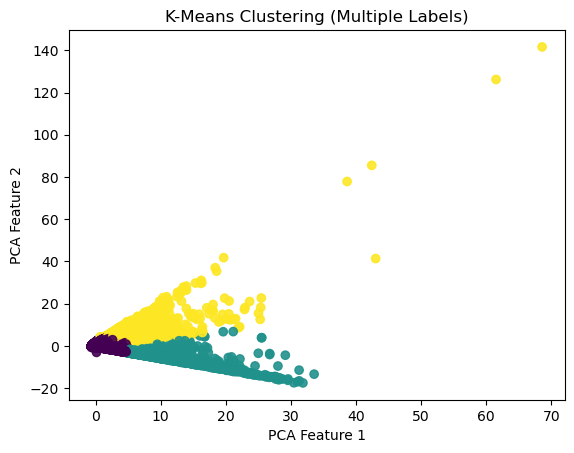

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_2d)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_kmeans, cmap='viridis', alpha=0.9)
plt.title("K-Means Clustering (Multiple Labels)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()


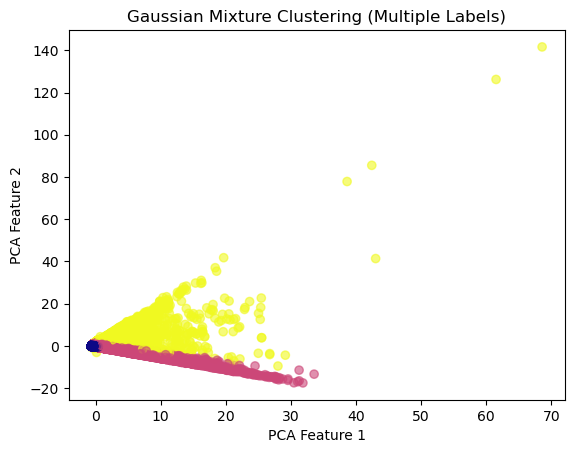

In [7]:
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_2d)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_gmm, cmap='plasma', alpha=0.6)
plt.title("Gaussian Mixture Clustering (Multiple Labels)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()

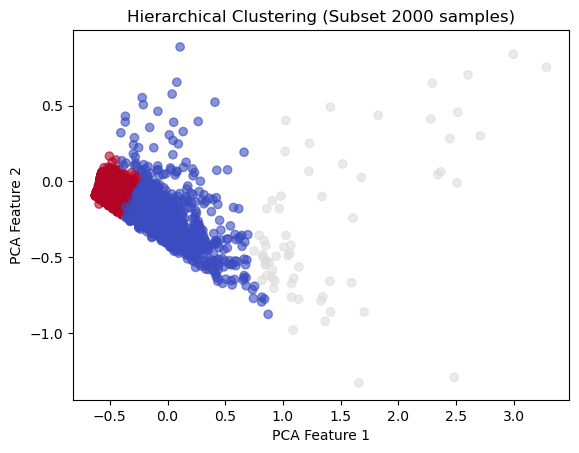

In [10]:
# Take only first 2000 samples (to avoid memory issue)
sample_df = X_2d[:2000]

hier = AgglomerativeClustering(n_clusters=3)
labels_hier = hier.fit_predict(sample_df)

plt.scatter(sample_df[:,0], sample_df[:,1], c=labels_hier, cmap='coolwarm', alpha=0.6)
plt.title("Hierarchical Clustering (Subset 2000 samples)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()


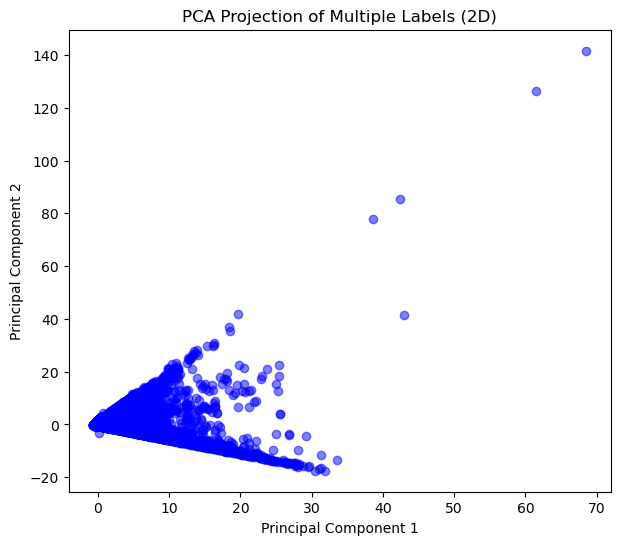

Explained Variance Ratio: [0.31611627 0.22959397]


In [11]:
# Practice 2: PCA Visualization
# -----------------------------
plt.figure(figsize=(7,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c='blue', alpha=0.5)
plt.title("PCA Projection of Multiple Labels (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)